# 🚀 Spaceship Titanic: Model & Dataset Preset Cross-Benchmarking

# Setup & Environment Configuration

In [1]:
# Import project pipeline modules
from src import (SpaceShipDataset, ModelTrainer, CatBoostTrainer, LightGBMTrainer, XGBoostTrainer, RandomForestTrainer, GradientBoostingTrainer,
                 LogisticRegressionTrainer, NeuralNetTrainer, compare_trainers, plot_benchmark_heatmaps, plot_model_sensitivity, plot_ensemble_consensus, 
                 save_submission, train_ensemble_models, DATASET_PRESETS, MODEL_PRESETS)
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import time
import sys
import os

warnings.filterwarnings("ignore")

# Configure visual style
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "Helvetica"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

print("🚀 Environment loaded successfully!")
print(f"• Dataset Presets Available: {len(DATASET_PRESETS)} ({list(DATASET_PRESETS.keys())})")
print(f"• Model Presets Available: {len(MODEL_PRESETS)} ({list(MODEL_PRESETS.keys())})")

/Users/fabioschiliro/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Environment loaded successfully!
• Dataset Presets Available: 5 (['baseline', 'drop_missing', 'aggregated_spending_only', 'raw_spending_only', 'linear_optimized'])
• Model Presets Available: 7 (['catboost', 'lightgbm', 'xgboost', 'random_forest', 'gradient_boosting', 'logistic_regression', 'neural_net'])


## Overview of Dataset Presets
The `SpaceShipDataset` pipeline supports different preprocessing presets designed to test various hypotheses about missing data handling, feature engineering, collinearity and categorical encoding.

Let's inspect the configuration and preprocessing choices for each available preset.


In [2]:
# Summarize available dataset presets
presets_summary = []

for name, cfg in DATASET_PRESETS.items():
    presets_summary.append({
                                "Preset Name": name,
                                "Missing Values Strategy": cfg.get("missing_strategy", "impute"),
                                "Introduce Spending Aggs": cfg.get("introduce_features", False),
                                "Drop Individual Amenities": cfg.get("drop_original_amenities", False),
                                "Has_Spent Indicator": cfg.get("include_has_spent", False),
                                "Is_Solo Indicator": cfg.get("include_is_solo", True),
                                "Categorical Encoding": cfg.get("encoding_strategy", "auto"),
                                "Scale Numeric": cfg.get("scale_numeric", True),
                                "Description": cfg.get("description", "")
                            })

presets_df = pd.DataFrame(presets_summary)
presets_df[["Preset Name", "Missing Values Strategy", "Introduce Spending Aggs", 
            "Drop Individual Amenities", "Has_Spent Indicator", "Is_Solo Indicator", 
            "Categorical Encoding", "Scale Numeric"]]

,Preset Name,Missing Values Strategy,Introduce Spending Aggs,Drop Individual Amenities,Has_Spent Indicator,Is_Solo Indicator,Categorical Encoding,Scale Numeric
0,baseline,impute,True,False,True,True,auto,True
1,drop_missing,drop,True,False,True,True,auto,True
2,aggregated_spending_only,impute,True,True,True,True,auto,True
3,raw_spending_only,impute,False,False,False,True,auto,True
4,linear_optimized,impute,False,True,False,False,auto,True


## Pre-building & Splitting All Dataset Presets

To guarantee a fair benchmark:

- Each preset is built via `SpaceShipDataset.build()`.

- Each dataset is split using `ModelTrainer.create_data_splits()` with an identical `random_state = 42`, `test_size = 0.20`, and `val_size = 0.20`.

- All models evaluated on a preset share the exact same clean, untouched test holdout set.

Pre-building and caching all splits in memory avoids redundant preprocessing during training.

In [3]:
# Dictionary to store preprocessed DataSplit containers for each preset
dataset_splits = {}
competition_test_data = {}

print("Building and caching dataset presets...")
build_logs = []

for preset_name in DATASET_PRESETS.keys():

    t0 = time.time()
    X, y, X_comp = SpaceShipDataset.build(preset = preset_name, dir = "./dataset", verbose = False)
    
    # Create standardized Train / Validation / Shared Test holdout splits
    splits = ModelTrainer.create_data_splits(X = X, y = y, test_size = 0.20, val_size = 0.20, X_competition_test = X_comp, stratify = True, random_state = 42)
    
    dataset_splits[preset_name] = splits
    competition_test_data[preset_name] = X_comp
    elapsed = time.time() - t0
    
    build_logs.append({
                            "Preset": preset_name,
                            "Total Samples": len(X),
                            "Features": X.shape[1],
                            "Train Set": splits.X_train.shape[0],
                            "Val Set": splits.X_val.shape[0],
                            "Test Holdout": splits.X_test.shape[0],
                            "Build Time (s)": f"{elapsed:.2f}s"
                        })

build_df = pd.DataFrame(build_logs)
build_df

Building and caching dataset presets...


,Preset,Total Samples,Features,Train Set,Val Set,Test Holdout,Build Time (s)
0,baseline,8693,21,5215,1739,1739,0.28s
1,drop_missing,6606,21,3963,1321,1322,0.04s
2,aggregated_spending_only,8693,16,5215,1739,1739,0.25s
3,raw_spending_only,8693,19,5215,1739,1739,0.25s
4,linear_optimized,8693,18,5215,1739,1739,0.25s


# Systematic Cross-Model Training
We evaluate 7 model architectures across all 5 dataset presets (35 distinct experiments).

### Candidate Models:

1. **LogisticRegression** (`LogisticRegressionTrainer`): Linear baseline with L2 regularization.

2. **RandomForest** (`RandomForestTrainer`): Bagging ensemble of unpruned decision trees.

3. **GradientBoosting** (`GradientBoostingTrainer`): Scikit-Learn staged gradient boosting.

4. **LightGBM** (`LightGBMTrainer`): High-speed leaf-wise gradient boosted trees.

5. **XGBoost** (`XGBoostTrainer`): Depth-wise tree boosting with regularization.

6. **CatBoost** (`CatBoostTrainer`): Oblivious symmetric decision trees with robust categorical handling.

7. **NeuralNet** (`NeuralNetTrainer`): PyTorch multi-layer perceptron with BatchNorm, SiLU, and Dropout.

We track: **Accuracy**, **ROC-AUC**, **F1-Score**, **Precision**, **Recall**, **Log-Loss**, and **Training Runtime**.

In [4]:
# Model trainer registry
MODEL_TRAINER_CLASSES = {
                            "LogisticRegression": LogisticRegressionTrainer,
                            "RandomForest": RandomForestTrainer,
                            "GradientBoosting": GradientBoostingTrainer,
                            "LightGBM": LightGBMTrainer,
                            "XGBoost": XGBoostTrainer,
                            "CatBoost": CatBoostTrainer,
                            "NeuralNet": NeuralNetTrainer,
                        }

# Storage containers for experiment results and trained instances
benchmark_records = []
trained_models = {p: {} for p in DATASET_PRESETS.keys()}

total_experiments = len(DATASET_PRESETS) * len(MODEL_TRAINER_CLASSES)
exp_count = 0
start_time_all = time.time()

print(f"🚀 Launching Benchmark Matrix: {len(MODEL_TRAINER_CLASSES)} Models × {len(DATASET_PRESETS)} Presets = {total_experiments} Experiments\n" + "="*80)

for preset_name, splits in dataset_splits.items():

    print(f"\n📂 DATASET PRESET: [{preset_name}] (Features: {splits.X_train.shape[1]}, Train: {splits.X_train.shape[0]} samples)")
    print("-" * 80)
    
    for model_name, trainer_cls in MODEL_TRAINER_CLASSES.items():

        exp_count += 1
        t0 = time.time()
        
        # Instantiate trainer on current preset splits
        trainer = trainer_cls(data_split=splits)
        
        # Fit with model-appropriate training parameters
        if model_name in ["CatBoost", "LightGBM"]:
            trainer.fit(early_stopping_rounds = 30, verbose = False)

        elif model_name == "NeuralNet":
            trainer.fit(epochs = 20, batch_size = 64, verbose = False)
 
        else:
            trainer.fit()
            
        # Standardized evaluation on the shared, untouched test holdout
        metrics = trainer.evaluate_test(threshold = 0.5, verbose = False)
        elapsed = time.time() - t0
        
        # Save model and metrics
        trained_models[preset_name][model_name] = trainer
        record = {
                    "Preset": preset_name,
                    "Model": model_name,
                    "Accuracy": metrics["Accuracy"],
                    "ROC-AUC": metrics["ROC-AUC"],
                    "F1-Score": metrics["F1-Score"],
                    "Precision": metrics["Precision"],
                    "Recall": metrics["Recall"],
                    "Log-Loss": metrics["Log-Loss"],
                    "Train Time (s)": round(elapsed, 2)
                }
        benchmark_records.append(record)
        
        print(f"  [{exp_count:02d}/{total_experiments}] {model_name:<20} | Acc: {metrics['Accuracy']:.4f} | ROC-AUC: {metrics['ROC-AUC']:.4f} | F1: {metrics['F1-Score']:.4f} | Time: {elapsed:.2f}s")

total_duration = time.time() - start_time_all
print("\n" + "=" * 80)
print(f"✅ Full benchmark completed in {total_duration:.1f} seconds!")

🚀 Launching Benchmark Matrix: 7 Models × 5 Presets = 35 Experiments

📂 DATASET PRESET: [baseline] (Features: 21, Train: 5215 samples)
--------------------------------------------------------------------------------
  [01/35] LogisticRegression   | Acc: 0.7918 | ROC-AUC: 0.8773 | F1: 0.7950 | Time: 0.33s
  [02/35] RandomForest         | Acc: 0.8005 | ROC-AUC: 0.8933 | F1: 0.8023 | Time: 0.52s
  [03/35] GradientBoosting     | Acc: 0.8108 | ROC-AUC: 0.9060 | F1: 0.8127 | Time: 1.52s
  [04/35] LightGBM             | Acc: 0.8108 | ROC-AUC: 0.9064 | F1: 0.8138 | Time: 0.14s
  [05/35] XGBoost              | Acc: 0.8114 | ROC-AUC: 0.9044 | F1: 0.8119 | Time: 0.42s
  [06/35] CatBoost             | Acc: 0.8033 | ROC-AUC: 0.9073 | F1: 0.8079 | Time: 0.76s
  [07/35] NeuralNet            | Acc: 0.7867 | ROC-AUC: 0.8798 | F1: 0.7849 | Time: 4.75s

📂 DATASET PRESET: [drop_missing] (Features: 21, Train: 3963 samples)
--------------------------------------------------------------------------------
  [0

## Comprehensive Cross-Analysis & Comparative Visualizations
Now we analyze the cross-benchmarking results to understand which dataset preset is best suited for each model family.

In [5]:
# Create comprehensive benchmark DataFrame
results_df = pd.DataFrame(benchmark_records)

# Display top 15 highest performing configurations across all pairs
print("🏆 Top 15 Model & Dataset Preset Combinations (Ranked by Test Accuracy):")
top_15 = results_df.sort_values(by=["Accuracy", "ROC-AUC"], ascending = False).reset_index(drop = True).head(15)
top_15

🏆 Top 15 Model & Dataset Preset Combinations (Ranked by Test Accuracy):


,Preset,Model,Accuracy,ROC-AUC,F1-Score,Precision,Recall,Log-Loss,Train Time (s)
0,drop_missing,CatBoost,0.815431,0.909235,0.818722,0.810294,0.827327,0.374378,0.57
1,drop_missing,XGBoost,0.815431,0.905183,0.818182,0.812130,0.824324,0.388189,0.38
2,baseline,XGBoost,0.811386,0.904402,0.811927,0.815668,0.808219,0.386398,0.42
3,baseline,LightGBM,0.810811,0.906375,0.813809,0.806958,0.820776,0.380217,0.14
4,baseline,GradientBoosting,0.810811,0.905977,0.812749,0.810443,0.815068,0.381326,1.52
5,drop_missing,LightGBM,0.809380,0.905336,0.813333,0.802632,0.824324,0.382951,0.10
6,linear_optimized,XGBoost,0.809086,0.902805,0.808092,0.818501,0.797945,0.389334,0.38
7,linear_optimized,CatBoost,0.808511,0.905907,0.811331,0.805399,0.817352,0.379446,0.73
8,linear_optimized,LightGBM,0.807936,0.905366,0.809578,0.808656,0.810502,0.380530,0.13
9,drop_missing,GradientBoosting,0.807867,0.905268,0.811573,0.802053,0.821321,0.383758,1.12


### Performance Heatmaps (Accuracy & ROC-AUC)
A side-by-side heatmap matrix of **Models vs. Dataset Presets** provides instant visual clarity on model-data affinities.

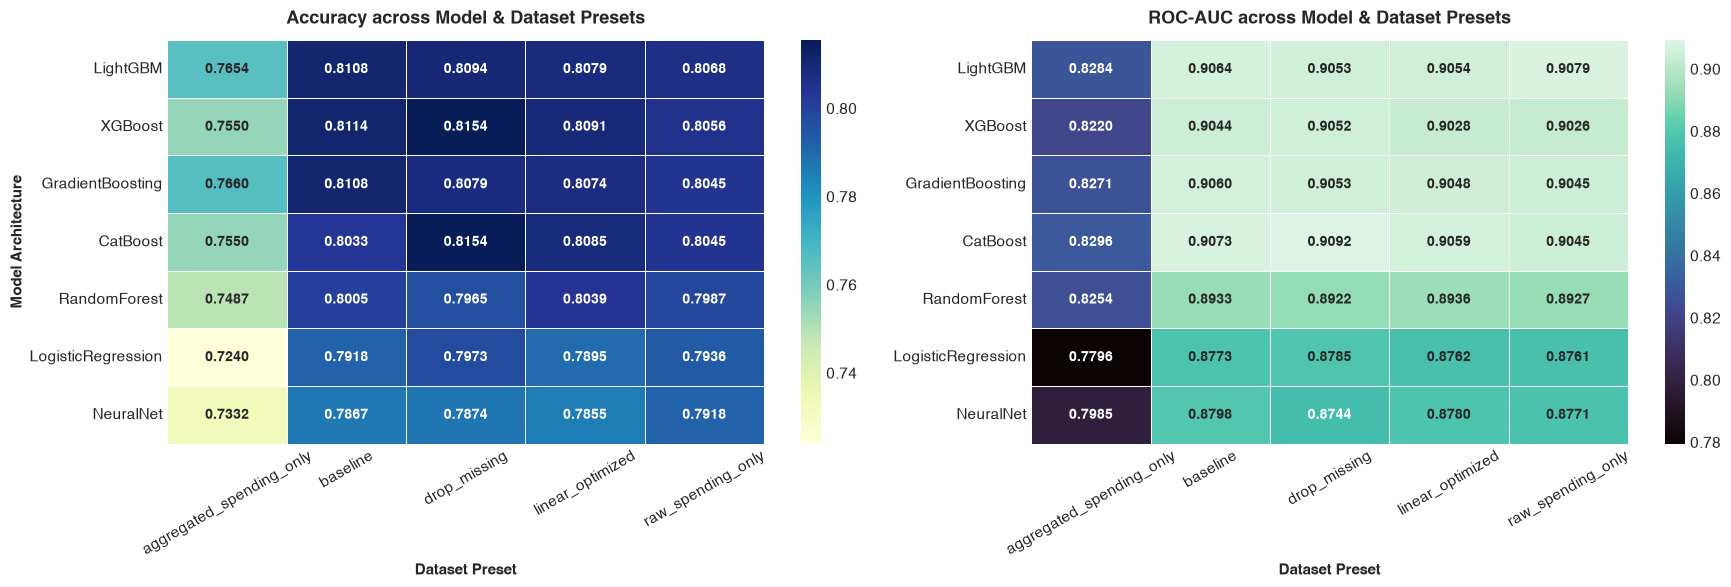

In [6]:
_ = plot_benchmark_heatmaps(results_df)

### Best Dataset Preset for Each Model
Which dataset representation extracts the strongest predictive signal from each algorithm?

In [7]:
# Determine the optimal preset per model
best_presets = []

for model_name in MODEL_TRAINER_CLASSES.keys():

    sub = results_df[results_df["Model"] == model_name]
    best_row = sub.sort_values(by = "Accuracy", ascending = False).iloc[0]
    worst_row = sub.sort_values(by = "Accuracy", ascending = True).iloc[0]
    best_presets.append({
                                    "Model": model_name,
                                    "Best Preset": best_row["Preset"],
                                    "Best Accuracy": f"{best_row['Accuracy']:.4f}",
                                    "Best ROC-AUC": f"{best_row['ROC-AUC']:.4f}",
                                    "Worst Preset": worst_row["Preset"],
                                    "Worst Accuracy": f"{worst_row['Accuracy']:.4f}",
                                    "Delta (Best - Worst)": f"+{(best_row['Accuracy'] - worst_row['Accuracy'])*100:.2f}%",
                                    "Training Time (s)": f"{best_row['Train Time (s)']:.2f}s"
                                })

best_preset_df = pd.DataFrame(best_presets).sort_values(by = "Best Accuracy", ascending = False).reset_index(drop = True)
best_preset_df

,Model,Best Preset,Best Accuracy,Best ROC-AUC,Worst Preset,Worst Accuracy,Delta (Best - Worst),Training Time (s)
0,XGBoost,drop_missing,0.8154,0.9052,aggregated_spending_only,0.7550,+6.04%,0.38s
1,CatBoost,drop_missing,0.8154,0.9092,aggregated_spending_only,0.7550,+6.04%,0.57s
2,GradientBoosting,baseline,0.8108,0.9060,aggregated_spending_only,0.7660,+4.49%,1.52s
3,LightGBM,baseline,0.8108,0.9064,aggregated_spending_only,0.7654,+4.54%,0.14s
4,RandomForest,linear_optimized,0.8039,0.8936,aggregated_spending_only,0.7487,+5.52%,0.44s
5,LogisticRegression,drop_missing,0.7973,0.8785,aggregated_spending_only,0.7240,+7.33%,0.28s
6,NeuralNet,raw_spending_only,0.7918,0.8771,aggregated_spending_only,0.7332,+5.87%,1.76s


### Model Sensitivity to Preprocessing Choices
Let's visualize each model's accuracy distribution and performance drop when amenity spending features are collapsed.


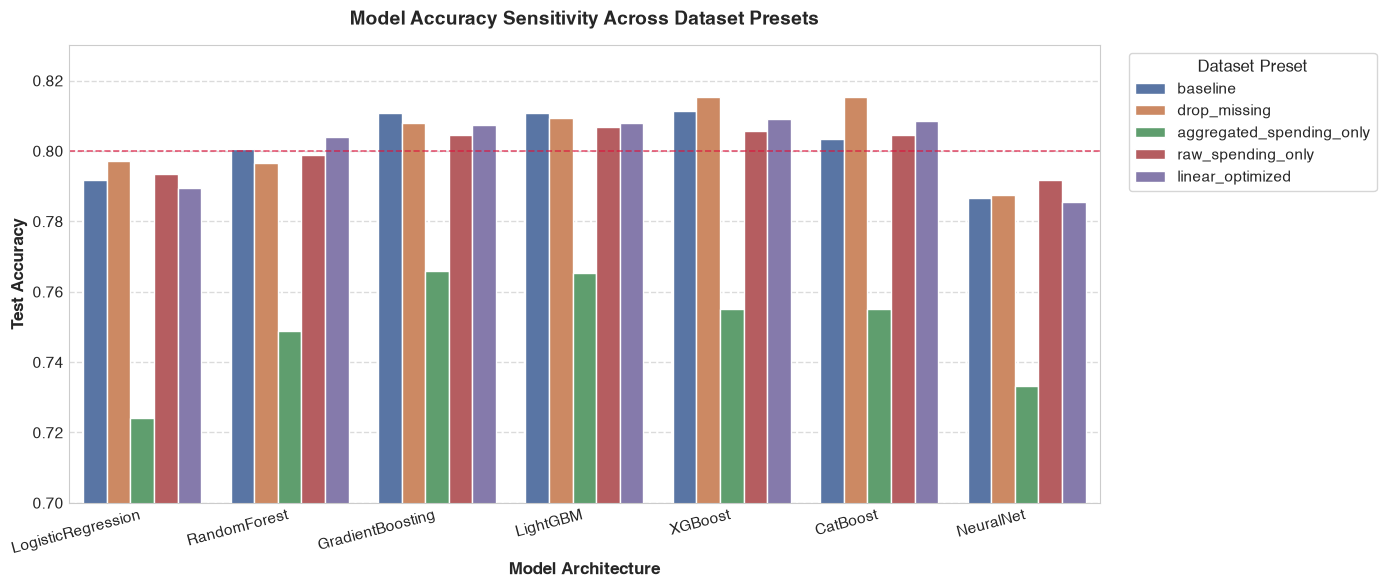

In [8]:
_ = plot_model_sensitivity(results_df)

### Overall Dataset Preset Ranking
How does each preprocessing strategy perform when averaged across all 7 model families?


In [9]:
preset_ranks = results_df.groupby("Preset").agg(
                                                        Mean_Accuracy = ("Accuracy", "mean"),
                                                        Max_Accuracy = ("Accuracy", "max"),
                                                        Mean_ROCAUC = ("ROC-AUC", "mean"),
                                                        Mean_F1 = ("F1-Score", "mean"),
                                                        Mean_Train_Time = ("Train Time (s)", "mean")

                                                    ).sort_values(by = "Mean_Accuracy", ascending = False).reset_index()

preset_ranks

,Preset,Mean_Accuracy,Max_Accuracy,Mean_ROCAUC,Mean_F1,Mean_Train_Time
0,drop_missing,0.804193,0.815431,0.895723,0.809763,0.620000
1,baseline,0.802185,0.811386,0.896350,0.804082,1.205714
2,linear_optimized,0.801692,0.809086,0.895251,0.803556,0.738571
3,raw_spending_only,0.800789,0.806786,0.895069,0.804189,0.704286
4,aggregated_spending_only,0.749610,0.765957,0.815804,0.728186,0.728571


## Full-Dataset Multi-Model Ensemble with Majority Voting

To maximize generalization and predictive accuracy on the Kaggle competition test set, we build a **5-model heterogeneous ensemble** combining the best model architectures:

| Model | Dataset Preset | Rationale |
| :--- | :---: | :--- |
| **NeuralNet** | `linear_optimized` | Scaled, collinearity-free tabular representation optimized for deep learning gradients. |
| **LightGBM** | `aggregated_spending_only` | Fast leaf-wise boosting on full hybrid-imputed feature space. |
| **GradientBoosting** | `baseline` | Classic staged boosting providing stable probability estimation. |
| **XGBoost** | `aggregated_spending_only` | Depth-wise tree boosting trained on high-purity non-imputed samples. |
| **CatBoost** | `raw_spending_only` | Symmetric oblivious trees with ordered statistics on high-purity samples. |

<br></br>

> **Full Dataset Training**: each model is trained on the **entire labeled dataset** (all training rows, without reserving validation or test splits) to maximize sample efficiency and leverage 100% of the training data.
>
> **Majority Voting Rule**: For each of the 4,277 competition test passengers, each model casts a binary vote (`True` / `False`) based on its calibrated threshold. If **3 or more models** vote `True`, the ensemble predicts `Transported = True`.

In [10]:
# Load entire datasets for all required presets (no validation/test split reservation)
ensemble_presets = ["linear_optimized", "baseline", "drop_missing", "aggregated_spending_only", "raw_spending_only"]
full_datasets = {}

print("📂 Loading full datasets for ensemble training...")
for preset_name in ensemble_presets:

    t0 = time.time()
    X_full, y_full, X_comp = SpaceShipDataset.build(preset = preset_name, dir = "./dataset", verbose = False)
    full_datasets[preset_name] = {"X_train": X_full, "y_train": y_full, "X_test": X_comp}
    print(f"  • Preset '{preset_name:<16}': Full Train Shape = {X_full.shape}, Competition Test Shape = {X_comp.shape} ({time.time()-t0:.2f}s)")

📂 Loading full datasets for ensemble training...
  • Preset 'linear_optimized': Full Train Shape = (8693, 18), Competition Test Shape = (4277, 18) (0.26s)
  • Preset 'baseline        ': Full Train Shape = (8693, 21), Competition Test Shape = (4277, 21) (0.25s)
  • Preset 'drop_missing    ': Full Train Shape = (6606, 21), Competition Test Shape = (4277, 21) (0.04s)
  • Preset 'aggregated_spending_only': Full Train Shape = (8693, 16), Competition Test Shape = (4277, 16) (0.25s)
  • Preset 'raw_spending_only': Full Train Shape = (8693, 19), Competition Test Shape = (4277, 19) (0.25s)


In [25]:
# Define the 5 ensemble model configurations
ensemble_specs = [
                    {
                        "name": "NeuralNet",
                        "trainer_cls": NeuralNetTrainer,
                        "preset": "linear_optimized",
                        "threshold": 0.5,
                        "fit_kwargs": {"epochs": 25, "batch_size": 32, "verbose": False},
                    },

                    {
                        "name": "LightGBM",
                        "trainer_cls": LightGBMTrainer,
                        "preset": "aggregated_spending_only",
                        "threshold": 0.5,
                        "fit_kwargs": {"verbose": False},
                    },

                    {
                        "name": "GradientBoosting",
                        "trainer_cls": GradientBoostingTrainer,
                        "preset": "baseline",
                        "threshold": 0.50,
                        "fit_kwargs": {},
                    },

                    {
                        "name": "XGBoost",
                        "trainer_cls": XGBoostTrainer,
                        "preset": "aggregated_spending_only",
                        "threshold": 0.50,
                        "fit_kwargs": {"verbose": False},
                    },

                    {
                        "name": "CatBoost",
                        "trainer_cls": CatBoostTrainer,
                        "preset": "raw_spending_only",
                        "threshold": 0.50,
                        "fit_kwargs": {"verbose": False},
                    }
]

# Train all models and generate predictions
fitted_ensemble_trainers, test_probabilities, test_predictions = train_ensemble_models(ensemble_specs = ensemble_specs, full_datasets = full_datasets)

🚀 Training 5 Ensemble Models on Full Datasets & Generating Test Predictions...
  ✓ NeuralNet          | Preset: linear_optimized | Threshold: 0.50 | Time: 14.49s | Predicted Transported: 2201/4277 (51.5%)
  ✓ LightGBM           | Preset: aggregated_spending_only | Threshold: 0.50 | Time:  0.14s | Predicted Transported: 1844/4277 (43.1%)
  ✓ GradientBoosting   | Preset: baseline         | Threshold: 0.50 | Time:  2.13s | Predicted Transported: 2205/4277 (51.6%)
  ✓ XGBoost            | Preset: aggregated_spending_only | Threshold: 0.50 | Time:  0.31s | Predicted Transported: 1857/4277 (43.4%)
  ✓ CatBoost           | Preset: raw_spending_only | Threshold: 0.50 | Time:  1.23s | Predicted Transported: 2231/4277 (52.2%)
✅ All 5 ensemble models successfully trained on full datasets!


### Prediction Diversity & Majority Voting
An ensemble achieves its highest power when individual models are accurate yet diverse. Let's examine the correlation between model predictions and the distribution of votes.

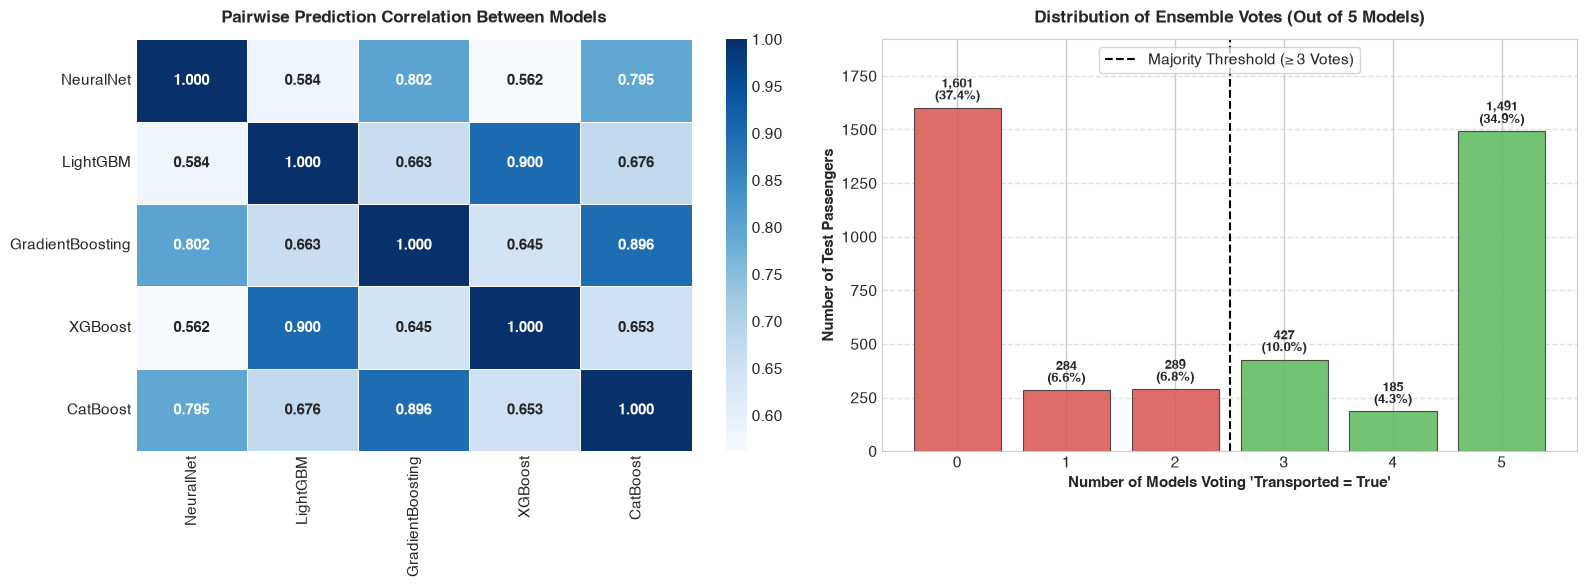


📊 Ensemble Consensus Summary:
  • Total Competition Test Passengers: 4,277
  • Unanimous Agreement (0 or 5 votes): 3,092 (72.3%)
  • Final Ensemble Transported = True:  2,103 (49.17%)
  • Final Ensemble Transported = False: 2,174 (50.83%)



In [26]:
ensemble_predictions = plot_ensemble_consensus(test_predictions, figsize = (16, 6))

### Generate and Save Official Kaggle Submission
Now we construct the final submission DataFrame and export it to `submissions/submission_file.csv`.


In [24]:
from src import save_submission
submission_df = save_submission(ensemble_predictions, output_path = "submissions/submission.csv")
submission_df.head(10)

💾 Official Ensemble Submission saved to: 'submissions/submission.csv'
• Total Rows: 4,277
• Null Values: 0

First 10 submission rows:


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
5,0027_01,False
6,0029_01,True
7,0032_01,True
8,0032_02,True
9,0033_01,True


## Hyperparameter Tuning Reference (Single-Model Tuning)
For future experimentation or single-model submission generation, you can also use each trainer's built-in `.tune_hyperparameters()` method on a specific dataset split:


In [14]:
# Reference: Quick single-model hyperparameter tuning example
splits_ref = dataset_splits["baseline"]
example_tuner = LightGBMTrainer(data_split = splits_ref)

best_params = example_tuner.tune_hyperparameters(
                                                    preset = "fast",
                                                    search_type = "grid",
                                                    cv = 3,
                                                    scoring = "accuracy",
                                                    verbose = True
                                                )

example_tuner.fit(early_stopping_rounds = 30, verbose = False)
example_tuner.evaluate_test(threshold = 0.62, verbose = True)

⚙️ Running GRID search for LightGBM (Preset = 'fast', Number of Folds = 3)...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
  🏆 Best Score (accuracy): 0.8079
  🔧 Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'num_leaves': 15}
----------------------------------------------------------------------
     📊 LightGBM — Shared Test Holdout Results (Threshold: 0.620)      
----------------------------------------------------------------------
  • Accuracy       : 0.8016 (80.16%)
  • ROC-AUC        : 0.9073
  • F1-Score       : 0.7778
  • Precision      : 0.8922 (89.22%)
  • Recall         : 0.6895 (68.95%)
  • Log-Loss       : 0.3771
----------------------------------------------------------------------


{'Accuracy': 0.8016101207590569,
 'ROC-AUC': 0.9072584485468024,
 'F1-Score': 0.7778493238892467,
 'Precision': 0.8921713441654358,
 'Recall': 0.6894977168949772,
 'Log-Loss': 0.3770840263669478}